# **Flight Delay Analysis**

#1- Data Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("flight_data_2024.csv")

df.head()

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.describe()

# 2- Data Cleaning

In [ ]:
df.isnull().sum()

In [ ]:
df["cancelled"].value_counts()

In [ ]:
df_clean = df[df["cancelled"] == 0 ]

df_clean.shape

In [ ]:
df_clean = df_clean.rename(columns={
    "fl_date": "flight_date",
    "op_unique_carrier": "airline",
    "op_carrier_fl_num": "flight_number",
    "origin": "origin_airport",
    "origin_city_name": "origin_city",
    "origin_state_nm": "origin_state",
    "dest": "destination_airport",
    "dest_city_name": "destination_city",
    "dest_state_nm": "destination_state",
    "crs_dep_time": "scheduled_departure",
    "dep_time": "actual_departure",
    "dep_delay": "departure_delay",
    "crs_arr_time": "scheduled_arrival",
    "arr_time": "actual_arrival",
    "arr_delay": "arrival_delay",
    "air_time": "flight_time"
})

In [ ]:
df_clean.isnull().sum()

In [ ]:
df_clean["diverted"].value_counts()

In [ ]:
df_clean['flight_date'] = pd.to_datetime(df_clean['flight_date'])

In [ ]:
df_clean.duplicated().sum()

# 3- Exploratory Data Analysis (EDA)

In [ ]:
df_clean["airline"]

In [ ]:
airline_names = {
     "WN": "Southwest Airlines",
    "AA": "American Airlines",
    "DL": "Delta Air Lines",
    "OO": "SkyWest Airlines",
    "UA": "United Airlines",
    "YX": "Republic Airways",
    "NK": "Spirit Airlines",
    "MQ": "Envoy Air",
    "B6": "JetBlue Airways",
    "9E": "Endeavor Air",
    "OH": "PSA Airlines",
    "AS": "Alaska Airlines",
    "F9": "Frontier Airlines",
    "G4": "Allegiant Air",
    "HA": "Hawaiian Airlines"
}
df_clean["airline"] = df_clean["airline"].replace(airline_names)

In [ ]:
# Which airline operates the highest number of flights ?


df_clean["airline"].value_counts().sort_values(ascending=False)

In [ ]:
# Top 10 origin airport has the highest number of departing flights

df_clean["origin_airport"].value_counts().sort_values(ascending=False).head(10)

In [ ]:
# Which destination airport receives the highest number of flights?

df_clean['destination_airport'].value_counts().sort_values(ascending=False).head(10)

In [ ]:
# What is the average departure delay?

df_clean['departure_delay'].mean().round(2)

In [ ]:
# What is the average arrival delay across all flights?

df_clean['arrival_delay'].mean().round(2)

In [ ]:
# Which airline has the highest average arrival delay?

df_clean.groupby('airline')['arrival_delay'].mean().round(2).sort_values(ascending=False).head(10)

In [ ]:
# Which airport has the highest average arrival delay?

df_clean.groupby('destination_airport')['arrival_delay'].mean().round(2).sort_values(ascending=False).head(10)

In [ ]:
# What is the percentage of flights with arrival delays?

delayed_flights = df_clean[df_clean['arrival_delay'] > 0].shape[0]

total_flights = df_clean.shape[0]

delay_percentage = (delayed_flights / total_flights) * 100
round(delay_percentage, 2)




In [ ]:
# What is the percentage of flights were cancelled?

# df_clean[df_clean['cancelled'] == 1].shape

# Check if there are any cancelled flights

df_clean['cancelled'].value_counts()

In [ ]:
# How are arrival delays distributed across flights?

arrival_delays = df_clean[df_clean['arrival_delay'] > 0]['arrival_delay']

arrival_delays.head()

# 4- Data Visulazation

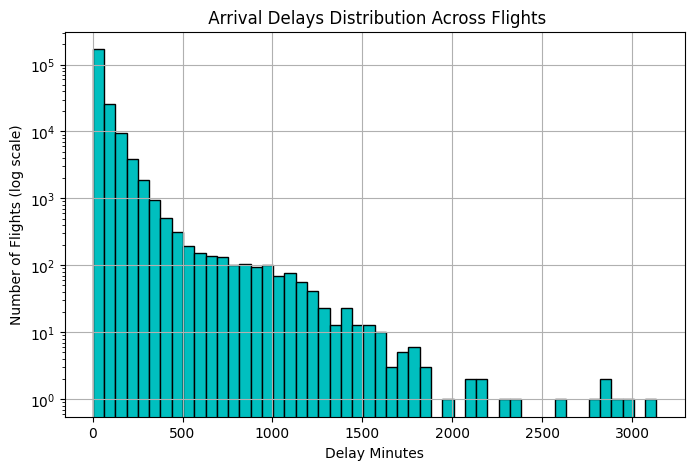

In [158]:
# 1.Histogram
# How are arrival delays distributed across flights?

all_delays = df_clean[df_clean['arrival_delay'] > 0]['arrival_delay']

plt.figure(figsize=(8,5))
plt.hist(all_delays, bins=50, color='c', edgecolor='black')
plt.yscale('log')
plt.title(" Arrival Delays Distribution Across Flights")
plt.xlabel("Delay Minutes")
plt.ylabel("Number of Flights (log scale)")
plt.grid(True)
plt.show()

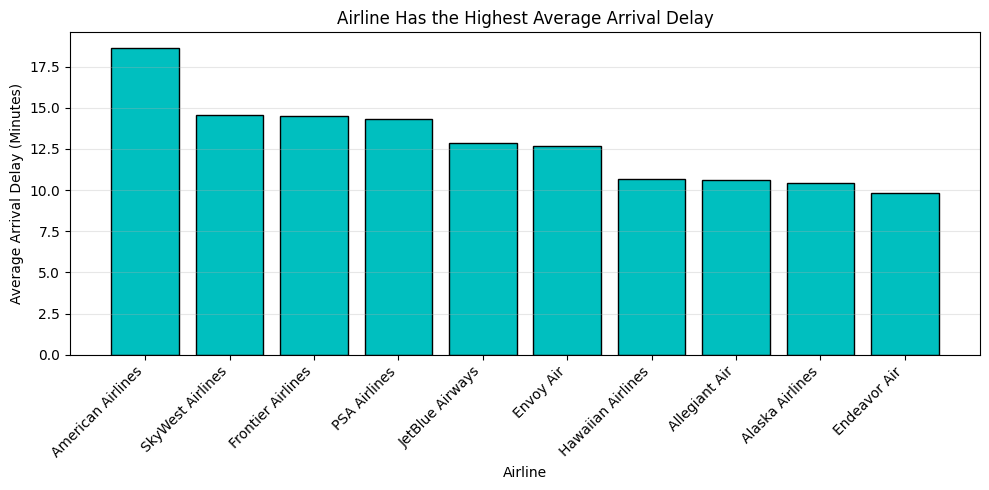

In [159]:
# 2.Bar Chart
# Which airline has the highest average arrival delay?
avg_delay_by_airline = df_clean.groupby('airline')['arrival_delay'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(avg_delay_by_airline.index, avg_delay_by_airline.values, color='c', edgecolor='black')
plt.title("Airline Has the Highest Average Arrival Delay")
plt.xlabel("Airline")
plt.ylabel("Average Arrival Delay (Minutes)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

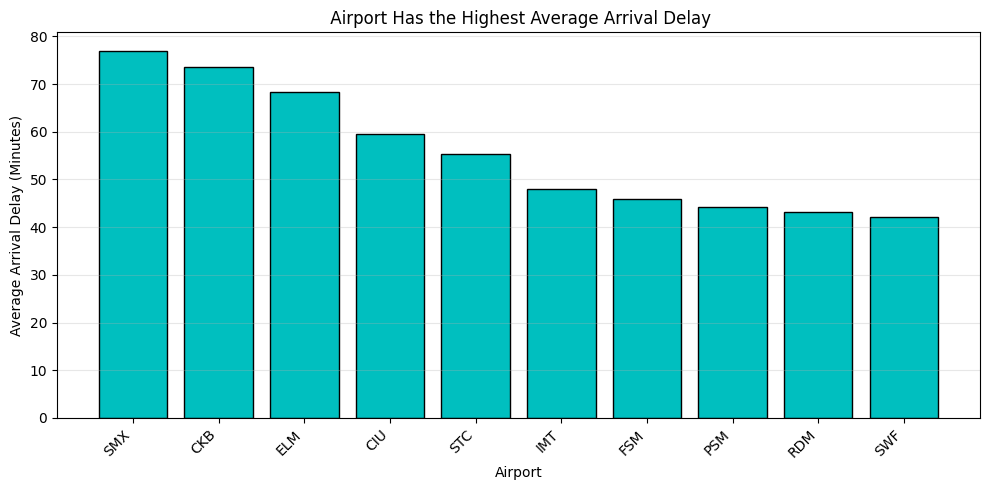

In [160]:
# 3.Bar Chart
# Which airport has the highest average arrival delay?
avg_delay_by_airport = df_clean.groupby('origin_airport')['arrival_delay'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(avg_delay_by_airport.index, avg_delay_by_airport.values, color='c', edgecolor='black')
plt.title(" Airport Has the Highest Average Arrival Delay")
plt.xlabel("Airport")
plt.ylabel("Average Arrival Delay (Minutes)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# **Insights**



1.**Data Exploration:**

     
    *   The dataset contains 539,121 flight records and 34 features, making it suitable for comprehensive flight delay analysis.
    *   The dataset includes information about airlines, airports, flight schedules, departure and arrival delays, and flight operations.
    *   Both numerical and categorical variables are available, allowing different types of statistical analysis and visualization.
    *   The flight_date column was converted to the appropriate datetime format to support time-based analysis.









2.**Data Cleaning:**


    *   Missing values were identified and handled to improve data quality.
    *   Duplicate records were checked and removed where necessary.
    *   Data types were verified and corrected to ensure accurate analysis.
    *   A cleaned dataset (df_clean) was created and used for all subsequent analyses.
    *   No cancelled flights were found in the cleaned dataset, as all records were marked as cancelled = 0.






3.**Exploratory Data Analysis (EDA)**


 ✈️ Airline Analysis


    *   American Airlines operated the highest number of flights in the dataset.
    *   American Airlines recorded the highest average arrival delay (18.64 minutes) among all airlines.
    *   Airlines showed noticeable differences in average arrival delays, indicating variations in operational performance.
    *   A higher average delay does not necessarily indicate poor airline performance, as delays can also be influenced by weather conditions, airport congestion, flight distance, and other operational factors.


🛫 Airport Analysis


    *   The busiest origin airports were identified based on the number of departing flights.
    *   The busiest destination airport was identified based on the number of arriving flights.
    *   CKB Airport recorded the highest average arrival delay (68.75 minutes) among all destination airports.


⏱ Delay Analysis


    *   The average arrival delay across all flights was 10.09 minutes.
    *   Approximately 39.49% of flights experienced arrival delays.
    *   The arrival delay distribution is right-skewed, indicating that most delayed flights experienced relatively short delays, while only a small number of flights had extremely long delays (outliers).
    *   Extreme delay values increased the overall average arrival delay.

❌ Cancelled Flights


    *   No cancelled flights were found in the cleaned dataset.
    *   All 539,121 flights were recorded as completed (cancelled = 0).

📊 Overall Findings


    *   Flight delays vary across airlines and airports.
    *   Most delayed flights experienced relatively short delays.
    *   Extreme delays were uncommon but had a noticeable impact on the overall average delay.
    *   The analysis highlights operational differences among airlines and airports, providing useful insights into flight delay patterns.

4.   **Data Visulazation:**


    *   Delay is driven by two separate factors: *who* operates the flight (airline) and *where* it operates (airport). Addressing arrival delays effectively would require looking at both dimensions together, rather than attributing the issue to a single cause.
    *  Most flights experienced relatively short arrival delays, while a small number of flights had extremely long delays, creating a right-skewed distribution.
